In [35]:
# ================================================
# CIEM5220 - Wave and Wind loads
#     Waterbound Windturbine 
#       STEP 5 - FREQUENCY
# ================================================

import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd().resolve()
for parent in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]:
    candidate = parent / "CIEM5220" / "Windturbine"
    if (candidate / "dynamics_tools.py").exists():
        NOTEBOOK_DIR = candidate
        break

sys.path.insert(0, str(NOTEBOOK_DIR))

import numpy as np
import matplotlib.pyplot as plt



In [36]:
#==== LOAD FEM RESULTS =====
fem=np.load(NOTEBOOK_DIR / 'outputs' / 'fem_results.npz')

freq =fem['freq']
omega=fem['omega']
eigenvectors=fem['eigenvectors']
K_free= fem['K_free']
M_free= fem['M_free']
C_free=fem['C_free']
D0 = float(fem['D0'])
le=float(fem['le'])
Hw=float(fem['Hw'])
Ha= float(fem['Ha'])
L=float(fem['L'])
elem_w=int(fem['elem_w'])
elem_a=int(fem['elem_a'])
ndof=int(fem['ndof'])
EI=float(fem['EI'])

elements=elem_w+elem_a
nodes=elements+1
f1=freq[0]
f2=freq[1]



In [37]:
# ===== LOAD SPECTRA RESULTS ======
spec=np.load(NOTEBOOK_DIR / 'outputs' / 'spectra_results.npz')

f_axis=spec['f_axis']
omega_axis=spec['omega_axis']
S_kaimal_LC1=spec['S_kaimal_LC1']
S_kaimal_LC2=spec['S_kaimal_LC2']
S_co_LC1=spec['S_co_LC1']
S_co_LC2=spec['S_co_LC2']
S_jonswap_LC1=spec['S_jonswap_LC1']
S_jonswap_LC2=spec['S_jonswap_LC2']
omega_p_LC1=float(spec['omega_p_LC1'])
omega_p_LC2=float(spec['omega_p_LC2'])
Hs_LC1=float(spec['Hs_LC1'])
Hs_LC2=float(spec['Hs_LC2'])
Tp_LC1=float(spec['Tp_LC1'])
Tp_LC2=float(spec['Tp_LC2'])
U_mean_LC1=spec['U_mean_LC1']
U_mean_LC2=spec['U_mean_LC2']
z_nodes=spec['z_nodes']
z_above=spec['z_above']
air_nodes=spec['air_nodes']

print(f"Loaded FEM and spectra results")
print(f"f1={f1:.4f} Hz, f2={f2:.4f} Hz")
print(f"ndof={ndof}, elem_w={elem_w}, elem_a={elem_a}")



Loaded FEM and spectra results
f1=0.1397 Hz, f2=1.2122 Hz
ndof=26, elem_w=3, elem_a=9


C:\Users\gabri\AppData\Local\Temp\ipykernel_33988\713428033.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  omega_p_LC1=float(spec['omega_p_LC1'])
C:\Users\gabri\AppData\Local\Temp\ipykernel_33988\713428033.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  omega_p_LC2=float(spec['omega_p_LC2'])
C:\Users\gabri\AppData\Local\Temp\ipykernel_33988\713428033.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Hs_LC1=float(spec['Hs_LC1'])
C:\Users\gabri\AppData\

In [38]:
# ==== FREQUENCY RESPONSE FUNCTION =====
# For each frewuency omega, solve:
#(-omega^2*M+i*omega*C+K)*U=F
# The FRF H(omega) relates nodal force to mudline moment

N_freq= len(omega_axis)
n_free=K_free.shape[0]



In [39]:
#mudline moment extraction vector
# moment at base = EI* d^2U/dx^2 at x=0 of element 0
# for clamped base this comes from the first free DOFs (nodes 1,2)
# M_mudline= EI*(6/le^2*u1-4/le*theta1-6/le^2*u+2/le*theta0)
#since u+)theta0=0 (clamped):M_mudline=EI*(6/le^2*u1-4/le*theta1)
#in free DOF vector: u1 is index 0, theta1 is index 1

e_moment=np.zeros(n_free)
e_moment[0]=EI*6/le**2 # coefficient for u1
e_moment[1]=EI*(-4)/le # coefficient for theta1



In [40]:
# frequency response function: H[node, freq]=mudline moment per unit force at node
H_moment=np.zeros((n_free, N_freq), dtype=complex)

for k, omk in enumerate(omega_axis):
    # dynamic stiffness matrix
    Z=(-omk**2*M_free+1j*omk*C_free+K_free)
    # solve for each unit force applied at each free DOF
    # columns of Z_inv give displacement per unit force
    Z_inv=np.linalg.solve(Z, np.eye(n_free))
    # mudline moment= e_moment @ Z_inv @ f
    H_moment[:, k]=e_moment @ Z_inv

print(f"\n Frequency Response Function")
print(f"H_moment shape: {H_moment.shape}")
print(f"Peak response at f1: {np.max(np.abs(H_moment)):.3e} Nm/N")




 Frequency Response Function
H_moment shape: (24, 1000)
Peak response at f1: 3.255e+03 Nm/N


In [41]:
# ==== WIND FORCE SPECTRUM =====
# linearised drag force per unit length: dF/dz=rho_air*Cd*D*U_mean*Su(f)
rho_air=1.25 # [kg/m^3]
Cd_wind=0.8 # drag coefficient for cylinder

# force spectrum at each air node
# S_F= (rho_air*Cd*D*U_mean)^2*S_u
n_air=len(air_nodes)

S_Fwind_LC1=np.zeros((n_air, N_freq))
S_Fwind_LC2=np.zeros((n_air, N_freq))

for i, node in enumerate(air_nodes):
    coeff_LC1=(rho_air*Cd_wind*D0*U_mean_LC1[node])**2
    coeff_LC2=(rho_air*Cd_wind*D0*U_mean_LC1[node])**2
    S_Fwind_LC1[i, :]=coeff_LC1*S_kaimal_LC1[i,:]
    S_Fwind_LC2[i, :]=coeff_LC1*S_kaimal_LC2[i,:]



In [42]:
# ==== WAVE FORCE SPECTRUM ======
# linearised Morison: dF/dz= rho_w*Cm*pi*D^2/4*du/dt (inertia)
#.                          + rho_w*Cd*D*u_rms*u (linearised drag)

rho_w=1025.0 # [kg/m^3]
Cm=2 # inertia coefficient
Cd_wave=1 # drag coefficient



In [43]:
# Wave number at each frequency
from dynamics_tools import wave_numbers

h= Hw
k_arr = wave_numbers(omega_axis, h)

# depth factor at each submerged node
z_sub_nodes=z_nodes[:elem_w+1]
n_sub=len(z_sub_nodes)

S_Fwave_LC1=np.zeros((n_sub, N_freq))
S_Fwave_LC2=np.zeros((n_sub, N_freq))

domega=omega_axis[1]-omega_axis[0]

for i, zi in enumerate(z_sub_nodes):
    z_from_surface=zi-h
    kh=k_arr*h
    depth_factor=np.where(
        kh<50, 
        np.cosh(k_arr*(z_from_surface+h))/np.sinh(kh),
        np.exp(k_arr*z_from_surface)
    )
    # inertia term transfer function
    H_inertia=rho_w*Cm*np.pi*D0**2/4*omega_axis*depth_factor
    # drag term - linearised using rms velocity
    u_rms_LC1= np.sqrt(np.sum(S_jonswap_LC1*omega_axis**2*depth_factor**2*domega))
    u_rms_LC2= np.sqrt(np.sum(S_jonswap_LC2*omega_axis**2*depth_factor**2*domega))
    H_drag_LC1=rho_w*Cd_wave*D0*u_rms_LC1*depth_factor
    H_drag_LC2=rho_w*Cd_wave*D0*u_rms_LC2*depth_factor

    S_Fwave_LC1[i,:]=(H_inertia + H_drag_LC1)**2*S_jonswap_LC1
    S_Fwave_LC2[i,:]=(H_inertia + H_drag_LC2)**2*S_jonswap_LC2

print(f"n Force Spectra")
print(f"Max wind force PSD LC1: {np.max(S_Fwind_LC1):.3e} N^2/Hz")
print(f"Max wind force PSD LC2: {np.max(S_Fwind_LC2):.3e} N^2/Hz")
print(f"Max wave force PSD LC1: {np.max(S_Fwave_LC1):.3e} N^2/Hz")
print(f"Max wave force PSD LC2: {np.max(S_Fwave_LC2):.3e} N^2/Hz")



n Force Spectra
Max wind force PSD LC1: 3.736e+04 N^2/Hz
Max wind force PSD LC2: 1.228e+05 N^2/Hz
Max wave force PSD LC1: 1.556e+09 N^2/Hz
Max wave force PSD LC2: 6.475e+09 N^2/Hz


C:\Users\gabri\AppData\Local\Temp\ipykernel_33988\1998090492.py:21: RuntimeWarning: overflow encountered in sinh
  np.cosh(k_arr*(z_from_surface+h))/np.sinh(kh),
C:\Users\gabri\AppData\Local\Temp\ipykernel_33988\1998090492.py:21: RuntimeWarning: overflow encountered in cosh
  np.cosh(k_arr*(z_from_surface+h))/np.sinh(kh),
C:\Users\gabri\AppData\Local\Temp\ipykernel_33988\1998090492.py:21: RuntimeWarning: invalid value encountered in divide
  np.cosh(k_arr*(z_from_surface+h))/np.sinh(kh),


In [44]:
# ===== MUDLINE MOMENT SPECTRUM =====
# S_MM(omega)=sum over all nodes of |H_node(omega)|^2*S_F_node(omega)
# plus cross terms from co-spectra for wind

S_MM_wind_LC1=np.zeros(N_freq)
S_MM_wind_LC2=np.zeros(N_freq)
S_MM_wave_LC1=np.zeros(N_freq)
S_MM_wave_LC2=np.zeros(N_freq)

# wind contribution - includes co-spectrum cross terms
for i in range (n_air):
    dof_i=2*(elem_w+i) # lateral DOF of this air node in free system
    fi=dof_i-2 # index in free DOF vector
    for j in range(n_air):
        dof_j=2*(elem_w+j)
        fj=dof_j-2
        S_MM_wind_LC1+= (np.abs(H_moment[fi])*
                         np.abs(H_moment[fj])*
                         S_co_LC1[i,j,:])
        S_MM_wind_LC2+= (np.abs(H_moment[fi])*
                         np.abs(H_moment[fj])*
                         S_co_LC2[i,j,:])
        
#wave contribution - nodes are uncorrelated so no cross terms
for i in range(n_sub):
    dof_i=2*i # lateral DOF of submerged node
    fi=dof_i-2 # index in free DOF vector
    if fi<0:
        continue # skip clamped base node
    S_MM_wave_LC1 += np.abs(H_moment[fi])**2*S_Fwave_LC1[i, :]
    S_MM_wave_LC2 += np.abs(H_moment[fi])**2*S_Fwave_LC2[i, :]

# total moment spectrum
S_MM_LC1=S_MM_wind_LC1+S_MM_wave_LC1
S_MM_LC2=S_MM_wind_LC2+S_MM_wave_LC2

print(f"\n Mudline Moment Spectrum")
print(f"std LC1 (wave): {np.sqrt(np.trapz(S_MM_wave_LC1, omega_axis))/1e6:.3f} MNm")
print(f"std LC1 (wind): {np.sqrt(np.trapz(S_MM_wind_LC1, omega_axis))/1e6:.3f} MNm")
print(f"std LC1 (total): {np.sqrt(np.trapz(S_MM_LC1, omega_axis))/1e6:.3f} MNm")
print(f"std LC2 (wave): {np.sqrt(np.trapz(S_MM_wave_LC2, omega_axis))/1e6:.3f} MNm")
print(f"std LC2 (wind): {np.sqrt(np.trapz(S_MM_wind_LC2, omega_axis))/1e6:.3f} MNm")
print(f"std LC2 (total): {np.sqrt(np.trapz(S_MM_LC2, omega_axis))/1e6:.3f} MNm")




 Mudline Moment Spectrum
std LC1 (wave): 2.601 MNm
std LC1 (wind): 0.001 MNm
std LC1 (total): 2.601 MNm
std LC2 (wave): 3.308 MNm
std LC2 (wind): 0.003 MNm
std LC2 (total): 3.308 MNm


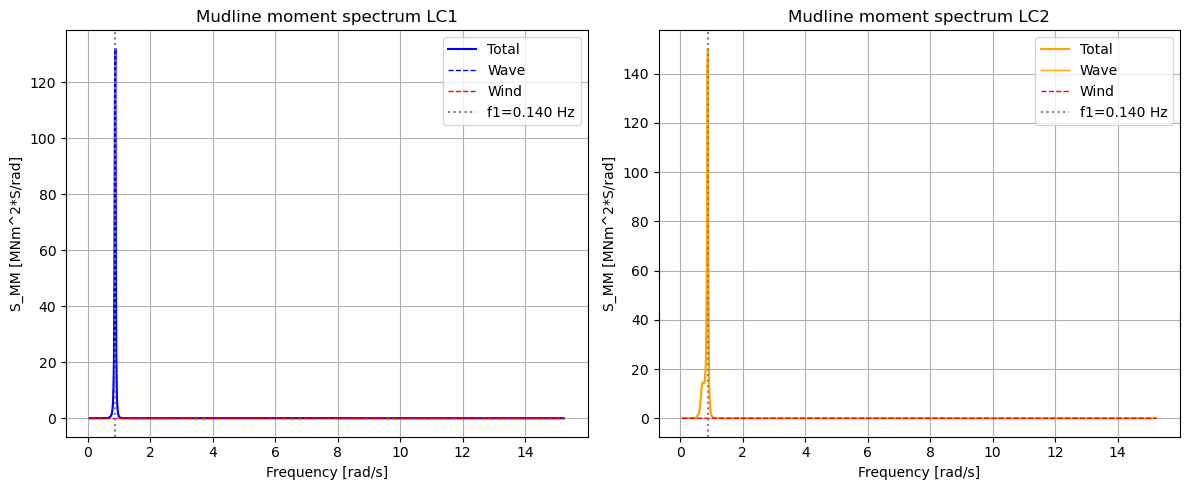

S_MM at f1 LC1: 132.01 MNm^2s/rad
S_MM at f1 LC2: 150.08 MNm^2s/rad


In [45]:
#======= PLOT MUDLINE MOMENT SPECTRUM =======

fig, axes= plt.subplots(1,2,figsize=(12,5))

axes[0].plot(omega_axis, S_MM_LC1/1e12, 'b', linewidth=1.5, label='Total')
axes[0].plot(omega_axis, S_MM_wave_LC1/1e12, 'b--', linewidth=1, label='Wave')
axes[0].plot(omega_axis, S_MM_wind_LC1/1e12, 'r--', linewidth=1, label='Wind')
axes[0].axvline(2*np.pi*f1, color='gray', linestyle=':', label=f'f1={f1:.3f} Hz')
axes[0].set_xlabel('Frequency [rad/s]')
axes[0].set_ylabel('S_MM [MNm^2*S/rad]')
axes[0].set_title('Mudline moment spectrum LC1')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(omega_axis, S_MM_LC2/1e12, 'orange', linewidth=1.5, label='Total')
axes[1].plot(omega_axis, S_MM_wave_LC2/1e12, 'orange', linewidth=1, label='Wave')
axes[1].plot(omega_axis, S_MM_wind_LC2/1e12, 'r--', linewidth=1, label='Wind')
axes[1].axvline(2*np.pi*f1, color='gray', linestyle=':', label=f'f1={f1:.3f} Hz')
axes[1].set_xlabel('Frequency [rad/s]')
axes[1].set_ylabel('S_MM [MNm^2*S/rad]')
axes[1].set_title('Mudline moment spectrum LC2')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

idx_f1=np.argmin(np.abs(omega_axis-2*np.pi*f1))
print(f"S_MM at f1 LC1: {S_MM_LC1[idx_f1]/1e12:.2f} MNm^2s/rad")
print(f"S_MM at f1 LC2: {S_MM_LC2[idx_f1]/1e12:.2f} MNm^2s/rad")



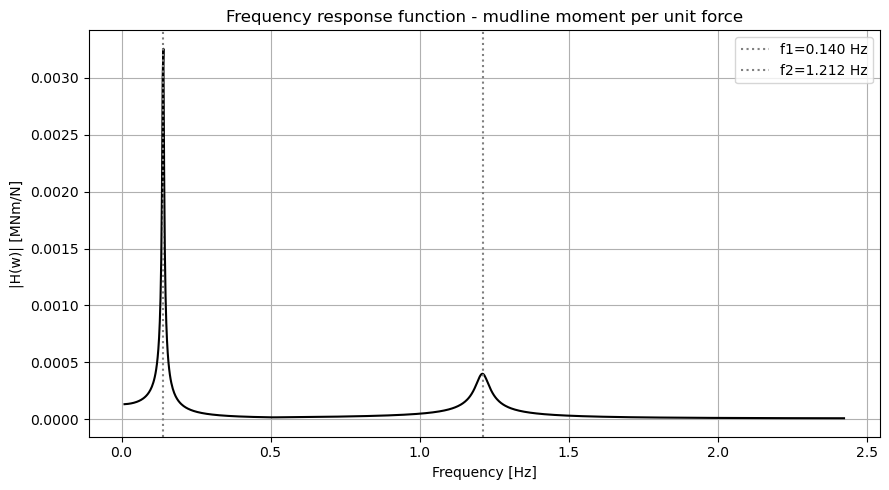

In [46]:
# ===== PLOT FRF =========
fig, ax=plt.subplots(figsize=(9,5))
ax.plot(omega_axis/(2*np.pi), np.max(np.abs(H_moment), axis=0)/1e6,
        'k', linewidth=1.5)
ax.axvline(f1, color='gray', linestyle=':', label=f'f1={f1:.3f} Hz')
ax.axvline(f2, color='gray', linestyle=':', label=f'f2={f2:.3f} Hz')
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('|H(w)| [MNm/N]')
ax.set_title('Frequency response function - mudline moment per unit force')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()



In [47]:
# ===== STATISTICAL QUANTITIES =====
# spectral moments
df=omega_axis[1]-omega_axis[0]

def spectral_moment(S, omega, n):
    return np.trapz(omega**n*S, omega)

# LC1
m0_LC1=spectral_moment(S_MM_LC1, omega_axis, 0)
m2_LC1=spectral_moment(S_MM_LC1, omega_axis, 2)
std_LC1=np.sqrt(m0_LC1)
Tz_LC1=2*np.pi*np.sqrt(m0_LC1/m2_LC1) # mean zero crossing period

# LC2
m0_LC2= spectral_moment(S_MM_LC2, omega_axis, 0)
m2_LC2= spectral_moment(S_MM_LC2, omega_axis, 2)
std_LC2=np.sqrt(m0_LC2)
Tz_LC2=2*np.pi*np.sqrt(m0_LC2/m2_LC2) 

print(f"\n Statistical Quantities")
print(f"LC1: std= {std_LC1/1e6:.3f} MNm, Tz= {Tz_LC1:.2f}")
print(f"LC2: std={std_LC2/1e6:.3f} MNm, {Tz_LC2:.2f}")




 Statistical Quantities
LC1: std= 2.601 MNm, Tz= 6.00
LC2: std=3.308 MNm, 6.17


In [48]:
#==== SAVE OUTPUTS =====
output_dir = NOTEBOOK_DIR / 'outputs'
output_dir.mkdir(parents=True, exist_ok=True)

np.savez(output_dir / 'frequency_results.npz',
    omega_axis=omega_axis,
    S_MM_LC1=S_MM_LC1,
    S_MM_LC2=S_MM_LC2,
    S_MM_wave_LC1=S_MM_wave_LC1,
    S_MM_wave_LC2=S_MM_wave_LC2,
    S_MM_wind_LC1=S_MM_wind_LC1,
    S_MM_wind_LC2=S_MM_wind_LC2,
    std_LC1=np.array([std_LC1]),
    std_LC2=np.array([std_LC2]),
    Tz_LC1=np.array([Tz_LC1]),
    Tz_LC2=np.array([Tz_LC2]),
    H_moment=H_moment
)
print("\nFrequency domain results saved to outputs/frequency_results.npz")



Frequency domain results saved to outputs/frequency_results.npz
